In [7]:
import os 
import warnings
import joblib
import numpy as  np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import(
    GridSearchCV,
    StratifiedKFold
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [8]:
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [9]:
X_train = pd.read_csv(
    "../data/processed/X_train.csv"
)

X_test = pd.read_csv(
    "../data/processed/X_test.csv"
)

# Scaled datasets
X_train_scaled = pd.read_csv(
    "../data/processed/X_train_scaled.csv"
)

X_test_scaled = pd.read_csv(
    "../data/processed/X_test_scaled.csv"
)

# Target datasets
y_train = pd.read_csv(
    "../data/processed/y_train.csv"
).squeeze()

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze()



In [10]:
cv_strategy = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)

In [11]:
logistic_model = LogisticRegression(

    max_iter=5000,

    random_state=42
)

logistic_params = {

    "C": [0.01, 0.1, 1, 10],

    "penalty": ["l1", "l2"],

    "solver": ["liblinear"]
}

In [12]:
knn_model = KNeighborsClassifier()

knn_params = {

    "n_neighbors": [3, 5, 7, 9, 11],

    "weights": ["uniform", "distance"],

    "metric": ["euclidean", "manhattan"]
}

In [13]:
svm_model = SVC(

    probability=True,

    random_state=42
)

svm_params = {

    "kernel": ["linear", "rbf", "poly"],

    "C": [0.1, 1, 10, 100],

    "gamma": ["scale", 0.1, 0.01, 0.001]
}

In [14]:
dt_model = DecisionTreeClassifier(

    random_state=42
)

dt_params = {

    "criterion": ["gini", "entropy"],

    "max_depth": [3, 5, 7, 10, None],

    "min_samples_split": [2, 5, 10],

    "min_samples_leaf": [1, 2, 5]
}

In [15]:
model_configs = {

    "Logistic Regression": {

        "model": logistic_model,

        "params": logistic_params,

        "X_train": X_train_scaled,

        "X_test": X_test_scaled
    },

    "KNN": {

        "model": knn_model,

        "params": knn_params,

        "X_train": X_train_scaled,

        "X_test": X_test_scaled
    },

    "SVM": {

        "model": svm_model,

        "params": svm_params,

        "X_train": X_train_scaled,

        "X_test": X_test_scaled
    },

    "Decision Tree": {

        "model": dt_model,

        "params": dt_params,

        "X_train": X_train,

        "X_test": X_test
    }
}

In [16]:
tuning_results = []

best_models = {}

for model_name, config in model_configs.items():

    print("=" * 70)

    print(f"Tuning Model: {model_name}")

    # ------------------------------------------------------
    # GET MODEL CONFIGURATION
    # ------------------------------------------------------

    model = config["model"]

    params = config["params"]

    X_train_use = config["X_train"]

    X_test_use = config["X_test"]

    # ------------------------------------------------------
    # GRID SEARCH
    # ------------------------------------------------------

    grid_search = GridSearchCV(

        estimator=model,

        param_grid=params,

        scoring="f1",

        cv=cv_strategy,

        n_jobs=-1,

        verbose=1
    )

    # ------------------------------------------------------
    # FIT GRID SEARCH
    # ------------------------------------------------------

    grid_search.fit(
        X_train_use,
        y_train
    )

    # ------------------------------------------------------
    # BEST MODEL
    # ------------------------------------------------------

    best_model = grid_search.best_estimator_

    best_models[model_name] = best_model

    # ------------------------------------------------------
    # PREDICTIONS
    # ------------------------------------------------------

    y_pred = best_model.predict(
        X_test_use
    )

    # ------------------------------------------------------
    # PROBABILITY PREDICTIONS
    # ------------------------------------------------------

    if hasattr(best_model, "predict_proba"):

        y_proba = best_model.predict_proba(
            X_test_use
        )[:, 1]

        roc_auc = roc_auc_score(
            y_test,
            y_proba
        )

    else:

        roc_auc = np.nan

    # ------------------------------------------------------
    # EVALUATION METRICS
    # ------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    # ------------------------------------------------------
    # SAVE BEST MODEL
    # ------------------------------------------------------

    model_filename = (

        model_name
        .lower()
        .replace(" ", "_")

        + "_tuned.pkl"
    )

    joblib.dump(

        best_model,

        f"../models/{model_filename}"
    )

    # ------------------------------------------------------
    # STORE RESULTS
    # ------------------------------------------------------

    tuning_results.append({

        "Model": model_name,

        "Best Parameters": str(
            grid_search.best_params_
        ),

        "Best CV F1": grid_search.best_score_,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "ROC AUC": roc_auc
    })

    # ------------------------------------------------------
    # PRINT RESULTS
    # ------------------------------------------------------

    print("\nBest Parameters:")

    print(grid_search.best_params_)

    print(f"\nBest CV F1 Score: {grid_search.best_score_:.4f}")

    print("\nTest Performance")

    print(f"Accuracy : {accuracy:.4f}")

    print(f"Precision: {precision:.4f}")

    print(f"Recall   : {recall:.4f}")

    print(f"F1 Score : {f1:.4f}")

    print(f"ROC AUC  : {roc_auc:.4f}")

    print("\nClassification Report")

    print(
        classification_report(
            y_test,
            y_pred
        )
    )



Tuning Model: Logistic Regression
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best Parameters:
{'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}

Best CV F1 Score: 0.6584

Test Performance
Accuracy : 0.7013
Precision: 0.5833
Recall   : 0.5185
F1 Score : 0.5490
ROC AUC  : 0.8098

Classification Report
              precision    recall  f1-score   support

           0       0.75      0.80      0.78       100
           1       0.58      0.52      0.55        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154

Tuning Model: KNN
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters:
{'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}

Best CV F1 Score: 0.6265

Test Performance
Accuracy : 0.7338
Precision: 0.6327
Recall   : 0.5741
F1 Score : 0.6019
ROC AUC  : 0.7930

Classification Report
              precision    recal

In [17]:
results_df = pd.DataFrame(
    tuning_results
)

results_df = results_df.sort_values(

    by=["F1 Score", "ROC AUC"],

    ascending=False

).reset_index(drop=True)

# Round numerical columns
numeric_cols = results_df.select_dtypes(
    include="number"
).columns

results_df[numeric_cols] = (
    results_df[numeric_cols]
    .round(4)
)

print("\nHyperparameter Tuning Results")

display(results_df)


Hyperparameter Tuning Results


,Model,Best Parameters,Best CV F1,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Decision Tree,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.5835,0.7597,0.6393,0.7222,0.6783,0.7622
1,KNN,"{'metric': 'euclidean', 'n_neighbors': 11, 'we...",0.6265,0.7338,0.6327,0.5741,0.6019,0.7930
2,Logistic Regression,"{'C': 0.1, 'penalty': 'l2', 'solver': 'libline...",0.6584,0.7013,0.5833,0.5185,0.5490,0.8098
3,SVM,"{'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}",0.6603,0.6948,0.5778,0.4815,0.5253,0.8169


In [19]:
results_df.to_csv(

    "../reports/hyperparameter_results.csv",

    index=False
)



In [20]:
best_model_name = results_df.iloc[0]["Model"]

best_model = best_models[best_model_name]

print("\nBest Tuned Model:", best_model_name)


Best Tuned Model: Decision Tree


In [21]:
joblib.dump(

    best_model,

    "../models/best_tuned_model.pkl"
)

print("Best tuned model saved successfully.")

Best tuned model saved successfully.


In [22]:
with open(

    "../models/best_tuned_model_name.txt",

    "w"

) as file:

    file.write(best_model_name)


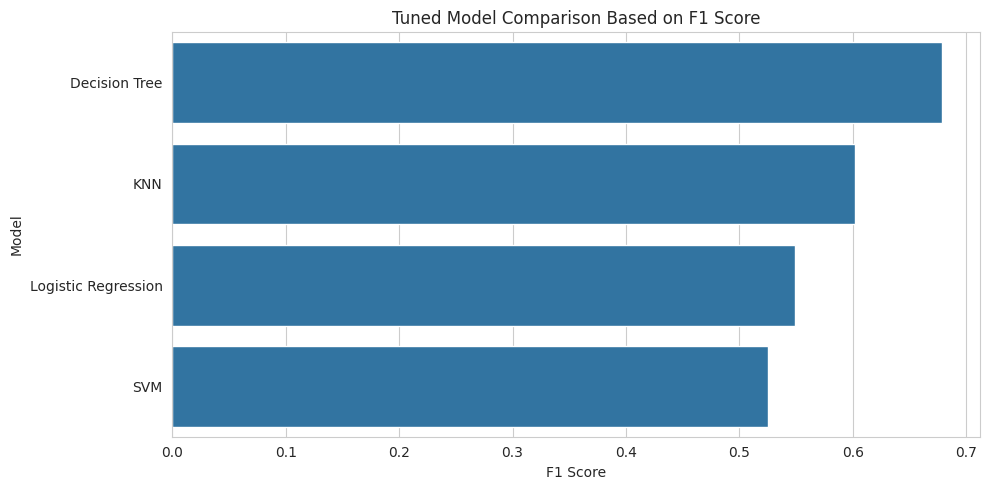

In [23]:
plt.figure(figsize=(10, 5))

sns.barplot(

    data=results_df,

    x="F1 Score",

    y="Model"
)

plt.title("Tuned Model Comparison Based on F1 Score")

plt.tight_layout()

plt.savefig(
    "../reports/figures/tuned_model_f1_comparison.png"
)

plt.show()

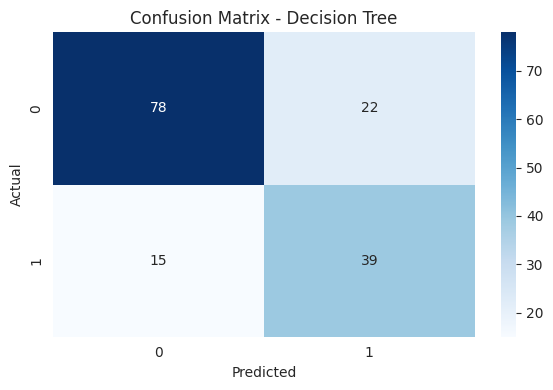

In [24]:
if best_model_name in [

    "Logistic Regression",

    "KNN",

    "SVM"
]:

    X_test_best = X_test_scaled

else:

    X_test_best = X_test

y_pred_best = best_model.predict(
    X_test_best
)

cm = confusion_matrix(
    y_test,
    y_pred_best
)

plt.figure(figsize=(6, 4))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "../reports/figures/tuned_best_model_confusion_matrix.png"
)

plt.show()

In [25]:
with open(

    "../reports/hyperparameter_tuning_summary.txt",

    "w"

) as file:

    file.write(
        "HYPERPARAMETER TUNING SUMMARY\n"
    )

    file.write("=" * 60 + "\n\n")

    file.write(
        f"Best Tuned Model: {best_model_name}\n\n"
    )

    file.write(
        results_df.to_string(index=False)
    )

print("Summary report saved successfully.")

Summary report saved successfully.
